In [1]:
import pandas as pd
import numpy as np
import math
import warnings
import string
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_score, KFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
warnings.filterwarnings("ignore")

<table class="table my-4 w-full"><thead><tr><th>Variable Name</th><th>Role</th><th>Type</th><th>Demographic</th><th>Description</th><th>Units</th><th>Missing Values</th></tr></thead> <tbody><tr><td>age</td><td>Feature</td><td>Integer</td><td>Age</td><td></td><td>years</td><td>no</td> </tr><tr><td>sex</td><td>Feature</td><td>Categorical</td><td>Sex</td><td></td><td></td><td>no</td> </tr><tr><td>cp</td><td>Feature</td><td>Categorical</td><td></td><td></td><td></td><td>no</td> </tr><tr><td>trestbps</td><td>Feature</td><td>Integer</td><td></td><td>resting blood pressure (on admission to the hospital)</td><td>mm Hg</td><td>no</td> </tr><tr><td>chol</td><td>Feature</td><td>Integer</td><td></td><td>serum cholestoral</td><td>mg/dl</td><td>no</td> </tr><tr><td>fbs</td><td>Feature</td><td>Categorical</td><td></td><td>fasting blood sugar &gt; 120 mg/dl</td><td></td><td>no</td> </tr><tr><td>restecg</td><td>Feature</td><td>Categorical</td><td></td><td></td><td></td><td>no</td> </tr><tr><td>thalach</td><td>Feature</td><td>Integer</td><td></td><td>maximum heart rate achieved</td><td></td><td>no</td> </tr><tr><td>exang</td><td>Feature</td><td>Categorical</td><td></td><td>exercise induced angina</td><td></td><td>no</td> </tr><tr><td>oldpeak</td><td>Feature</td><td>Integer</td><td></td><td>ST depression induced by exercise relative to rest</td><td></td><td>no</td> </tr><tr><td>slope</td><td>Feature</td><td>Categorical</td><td></td><td></td><td></td><td>no</td> </tr><tr><td>ca</td><td>Feature</td><td>Integer</td><td></td><td>number of major vessels (0-3) colored by flourosopy</td><td></td><td>yes</td> </tr><tr><td>thal</td><td>Feature</td><td>Categorical</td><td></td><td></td><td></td><td>yes</td> </tr><tr><td>num</td><td>Target</td><td>Integer</td><td></td><td>diagnosis of heart disease</td><td></td><td>no</td> </tr></tbody></table>

In [2]:
pcData = pd.read_csv("./processed.cleveland.data", delimiter= ",", header=None)

In [3]:
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]

In [4]:
pcData.columns = column_names

Having a look at the data

In [5]:
pcData.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
for col in pcData.columns:
    print(f"\nUnique values in column {col}:")
    print(pcData[col].unique())


Unique values in column age:
[63. 67. 37. 41. 56. 62. 57. 53. 44. 52. 48. 54. 49. 64. 58. 60. 50. 66.
 43. 40. 69. 59. 42. 55. 61. 65. 71. 51. 46. 45. 39. 68. 47. 34. 35. 29.
 70. 77. 38. 74. 76.]

Unique values in column sex:
[1. 0.]

Unique values in column cp:
[1. 4. 3. 2.]

Unique values in column trestbps:
[145. 160. 120. 130. 140. 172. 150. 110. 132. 117. 135. 112. 105. 124.
 125. 142. 128. 170. 155. 104. 180. 138. 108. 134. 122. 115. 118. 100.
 200.  94. 165. 102. 152. 101. 126. 174. 148. 178. 158. 192. 129. 144.
 123. 136. 146. 106. 156. 154. 114. 164.]

Unique values in column chol:
[233. 286. 229. 250. 204. 236. 268. 354. 254. 203. 192. 294. 256. 263.
 199. 168. 239. 275. 266. 211. 283. 284. 224. 206. 219. 340. 226. 247.
 167. 230. 335. 234. 177. 276. 353. 243. 225. 302. 212. 330. 175. 417.
 197. 198. 290. 253. 172. 273. 213. 305. 216. 304. 188. 282. 185. 232.
 326. 231. 269. 267. 248. 360. 258. 308. 245. 270. 208. 264. 321. 274.
 325. 235. 257. 164. 141. 252. 255. 201. 222.

In [7]:
print(pcData.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [8]:
columns_to_check = ['ca', 'thal']

data = pcData[columns_to_check].values

for i, col in enumerate(columns_to_check):
    count = np.sum(data[:, i] == '?')
    print(f"Missing entries in '{col}': {count}")

Missing entries in 'ca': 4
Missing entries in 'thal': 2


In [9]:
rows_with_missing = {}

for i, col in enumerate(columns_to_check):
    rows = np.where(data[:, i] == '?')[0]
    rows_with_missing[col] = rows

In [10]:
print(rows_with_missing['ca'].tolist())
print(rows_with_missing['thal'].tolist())

[166, 192, 287, 302]
[87, 266]


In [11]:
pcData[['ca', 'thal']] = pcData[['ca', 'thal']].replace('?', np.nan).astype(float)
pcData['ca'] = pcData['ca'].astype(float)
pcData['thal'] = pcData['thal'].astype(float)

pcData['ca_missing'] = pcData['ca'].isna().astype(int)
pcData['thal_missing'] = pcData['thal'].isna().astype(int)

In [12]:
pcData['target'] = (pcData['num'].astype(int) > 0).astype(int)
pcData.drop(columns=['num'], inplace=True)

In [13]:
pcData

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,ca_missing,thal_missing,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,0,0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,0,0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,0,0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,0,0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,0,0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,0,0,1


In [14]:
pcData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    float64
 1   sex           303 non-null    float64
 2   cp            303 non-null    float64
 3   trestbps      303 non-null    float64
 4   chol          303 non-null    float64
 5   fbs           303 non-null    float64
 6   restecg       303 non-null    float64
 7   thalach       303 non-null    float64
 8   exang         303 non-null    float64
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    float64
 11  ca            299 non-null    float64
 12  thal          301 non-null    float64
 13  ca_missing    303 non-null    int64  
 14  thal_missing  303 non-null    int64  
 15  target        303 non-null    int64  
dtypes: float64(13), int64(3)
memory usage: 38.0 KB


In [15]:
X = pcData.drop(columns=['target'])
y = pcData['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
iter_imputer = IterativeImputer(random_state=0)

train_imputed = iter_imputer.fit_transform(X_train[['ca', 'thal']])

X_train[['ca_imputed', 'thal_imputed']] = train_imputed
X_test[['ca_imputed', 'thal_imputed']] = iter_imputer.transform(X_test[['ca', 'thal']])

valid_ca_values = [0.0, 1.0, 2.0, 3.0]
valid_thal_values = [3.0, 6.0, 7.0]

def closest_category(x, valid_values):
    return min(valid_values, key=lambda val: abs(val - x))

X_train['ca'] = X_train['ca_imputed'].apply(lambda x: closest_category(x, valid_ca_values))
X_test['ca'] = X_test['ca_imputed'].apply(lambda x: closest_category(x, valid_ca_values))

X_train['thal'] = X_train['thal_imputed'].apply(lambda x: closest_category(x, valid_thal_values))
X_test['thal'] = X_test['thal_imputed'].apply(lambda x: closest_category(x, valid_thal_values))

X_train.drop(columns=['ca_imputed', 'thal_imputed'], inplace=True)
X_test.drop(columns=['ca_imputed', 'thal_imputed'], inplace=True)

In [17]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca_missing', 'thal_missing']

for col in cat_cols:
    X_train[col] = X_train[col].astype(float).astype(int).astype('category')
    X_test[col] = X_test[col].astype(float).astype(int).astype('category')

In [18]:
X_train.info()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 180 to 16
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           242 non-null    float64 
 1   sex           242 non-null    category
 2   cp            242 non-null    category
 3   trestbps      242 non-null    float64 
 4   chol          242 non-null    float64 
 5   fbs           242 non-null    category
 6   restecg       242 non-null    category
 7   thalach       242 non-null    float64 
 8   exang         242 non-null    category
 9   oldpeak       242 non-null    float64 
 10  slope         242 non-null    category
 11  ca            242 non-null    float64 
 12  thal          242 non-null    category
 13  ca_missing    242 non-null    category
 14  thal_missing  242 non-null    category
dtypes: category(9), float64(6)
memory usage: 16.6 KB
<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 219 to 155
Data columns (total 15 column

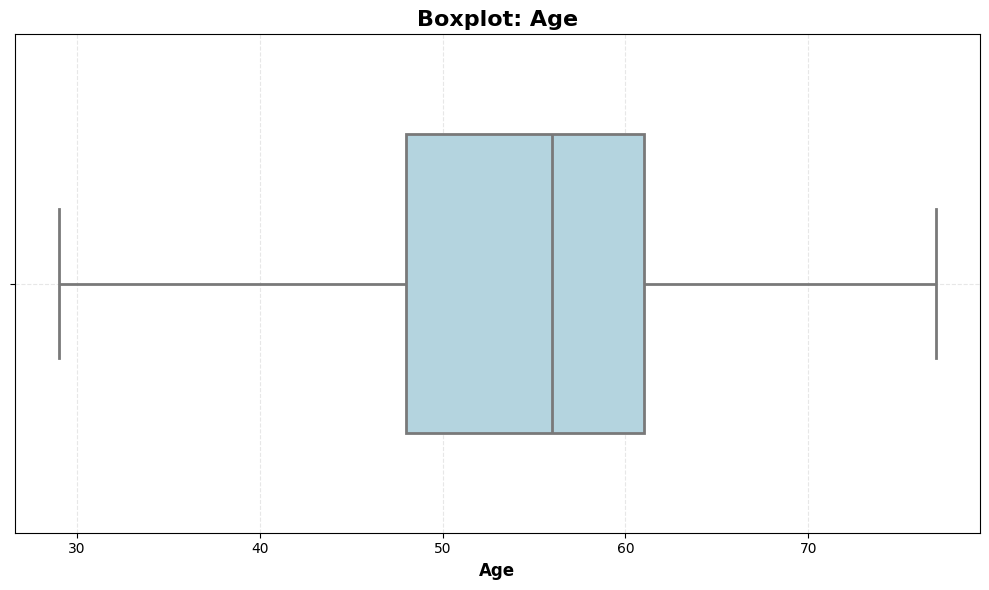

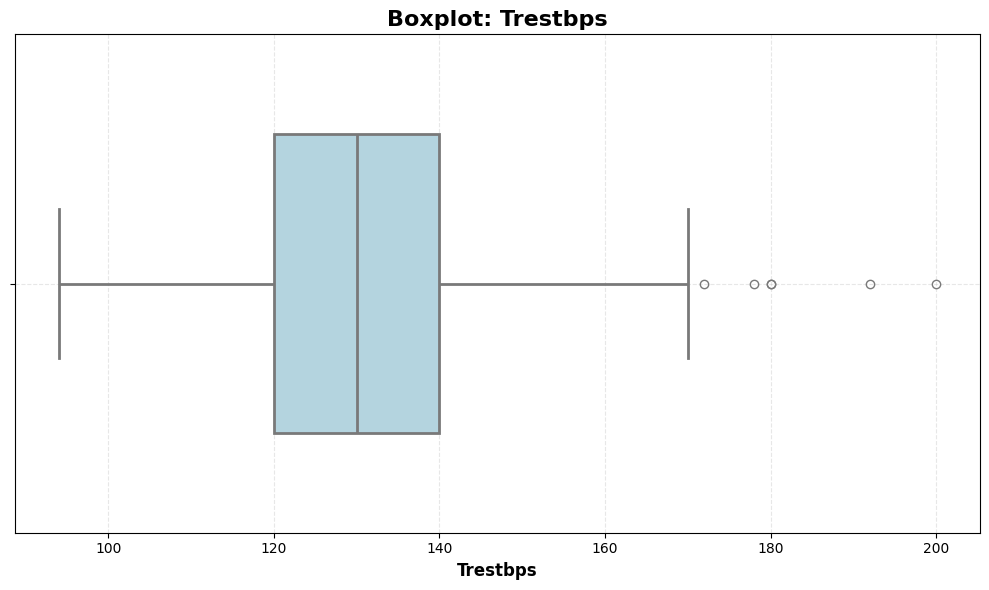


Outliers detected in 'trestbps':
[172. 180. 178. 200. 192. 180.]


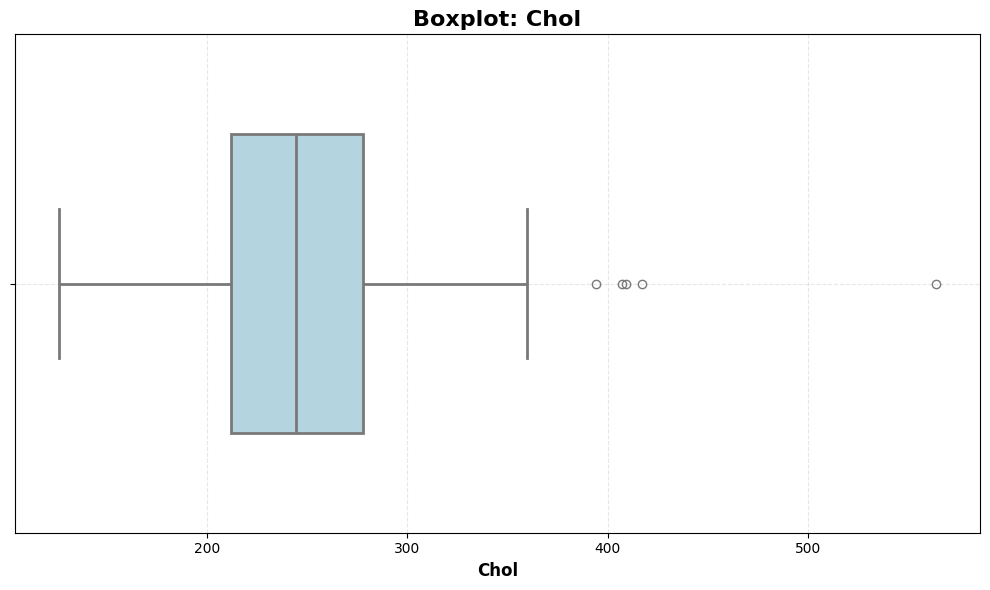


Outliers detected in 'chol':
[407. 417. 409. 564. 394.]


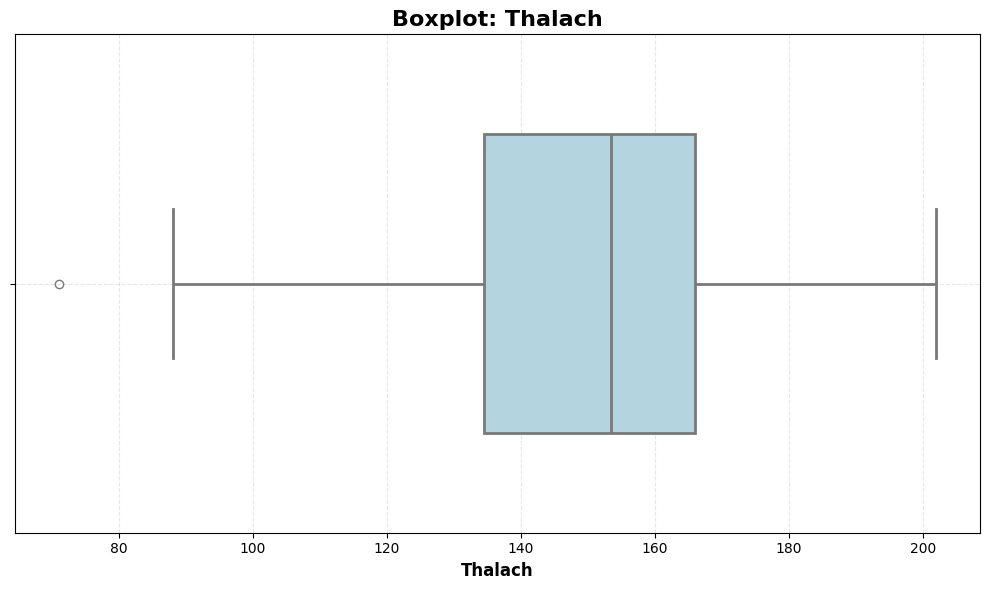


Outliers detected in 'thalach':
[71.]


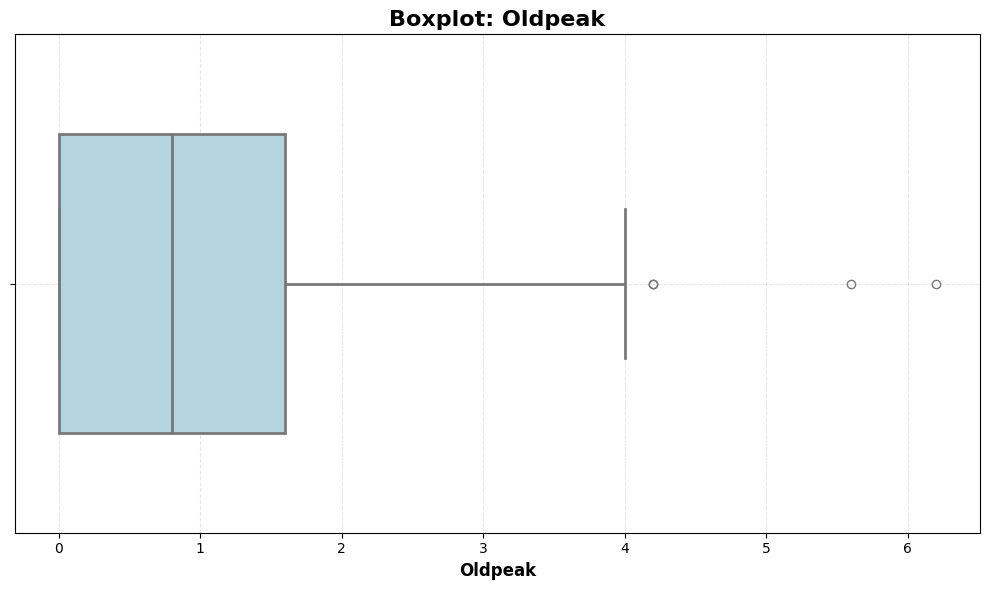


Outliers detected in 'oldpeak':
[5.6 6.2 4.2 4.2]


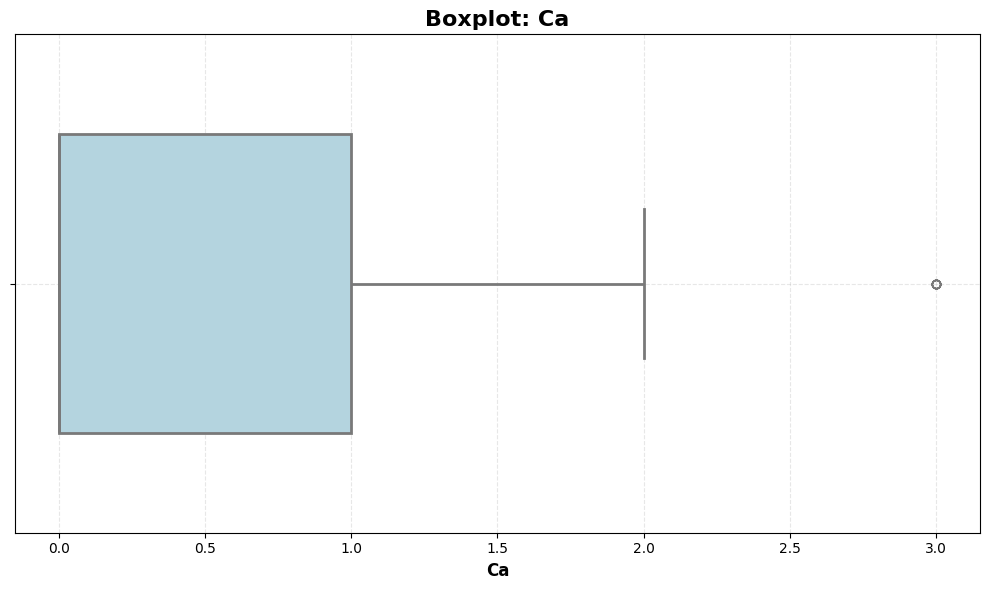


Outliers detected in 'ca':
[3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]


In [19]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

clip_bounds = {}
for col in numeric_cols:
    data = X_train[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    clip_bounds[col] = (lower_bound, upper_bound)

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data, color='lightblue', width=0.6, linewidth=2, whis=1.5)
    plt.title(f'Boxplot: {col.capitalize()}', fontsize=16, fontweight='bold')
    plt.xlabel(col.capitalize(), fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    if not outliers.empty:
        print(f"\nOutliers detected in '{col}':")
        print(outliers.values)

In [20]:
skewness = X_train[numeric_cols].skew().sort_values(ascending=False)
print("\nSkewness:\n", skewness)


Skewness:
 oldpeak     1.465713
ca          1.284504
chol        1.219506
trestbps    0.725117
age        -0.172393
thalach    -0.575394
dtype: float64


In [21]:
chol_clip = 400
oldpeak_clip = 5
trestbps_clip = 180

X_train['chol'] = X_train['chol'].clip(upper=chol_clip)
X_test['chol'] = X_test['chol'].clip(upper=chol_clip)

X_train['oldpeak'] = X_train['oldpeak'].clip(upper=oldpeak_clip)
X_test['oldpeak'] = X_test['oldpeak'].clip(upper=oldpeak_clip)

X_train['trestbps'] = X_train['trestbps'].clip(upper=trestbps_clip)
X_test['trestbps'] = X_test['trestbps'].clip(upper=trestbps_clip)

X_train['chol_log'] = np.log1p(X_train['chol'])
X_test['chol_log'] = np.log1p(X_test['chol'])

X_train['oldpeak_log'] = np.log1p(X_train['oldpeak'])
X_test['oldpeak_log'] = np.log1p(X_test['oldpeak'])

In [22]:
skewness = X_train[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'chol_log', 'oldpeak_log']].skew().sort_values(ascending=False)
print("\nSkewness:\n", skewness)


Skewness:
 ca             1.284504
oldpeak        1.259134
trestbps       0.541042
chol           0.502041
oldpeak_log    0.396522
chol_log      -0.147002
age           -0.172393
thalach       -0.575394
dtype: float64


In [23]:
X_train.drop(columns=['chol', 'oldpeak'], inplace=True)
X_test.drop(columns=['chol', 'oldpeak'], inplace=True)

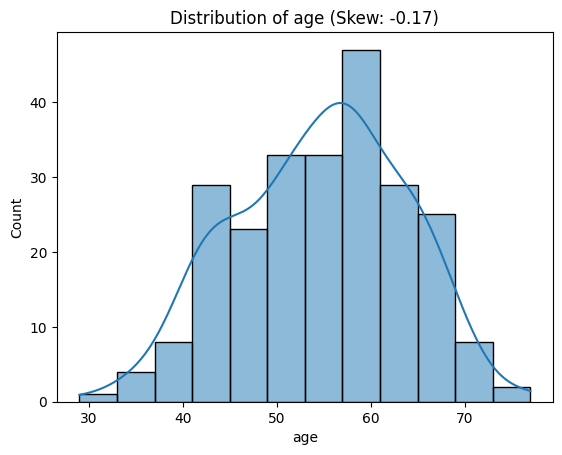

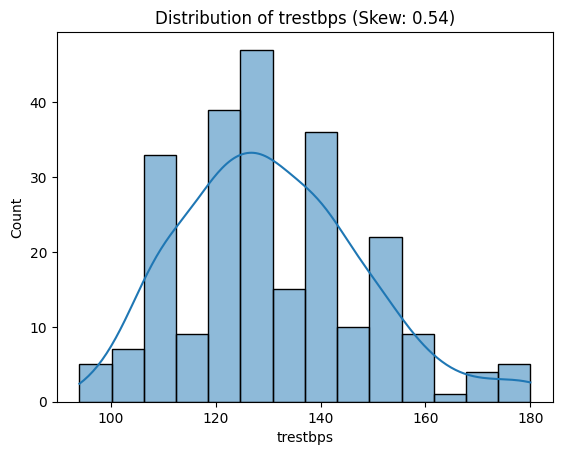

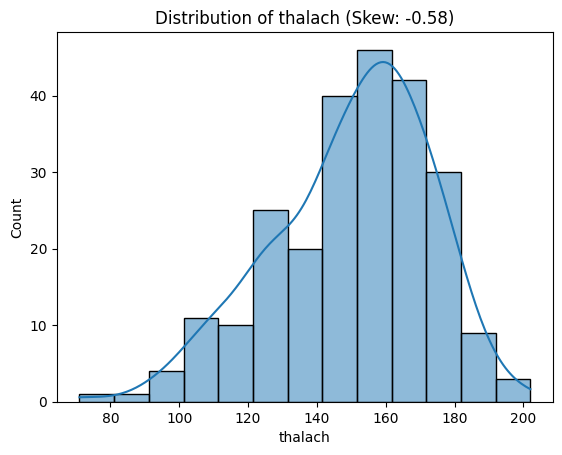

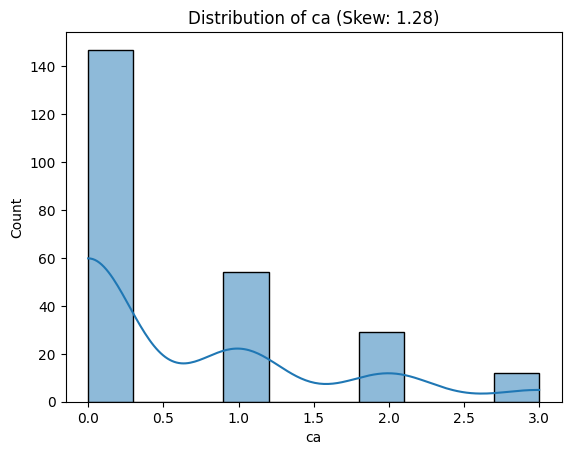

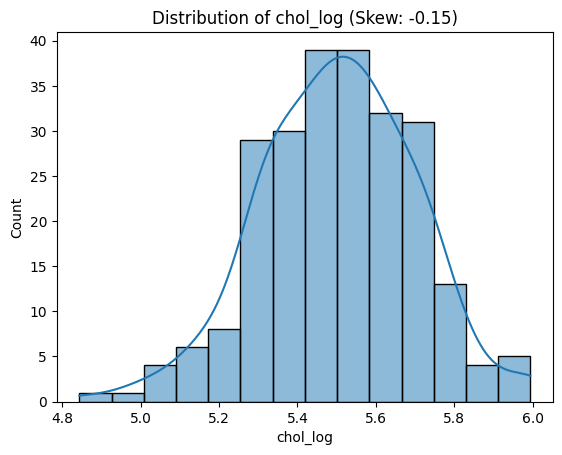

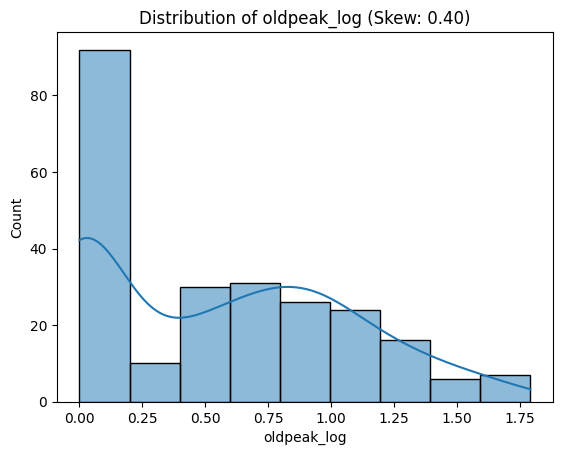

In [24]:
numeric_cols_new= ['age', 'trestbps', 'thalach', 'ca', 'chol_log', 'oldpeak_log']
for col in numeric_cols_new:
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col} (Skew: {X_train[col].skew():.2f})")
    plt.show()

In [25]:
features_to_scale = numeric_cols_new

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

joblib.dump(scaler, "std_scaler.pkl")

['std_scaler.pkl']

In [26]:
# def encode_categorical_features(df, categorical_cols, drop_first=True, sparse=False):
#     encoder = OneHotEncoder(drop='first' if drop_first else None,
#                             sparse_output=sparse,
#                             handle_unknown='ignore')
#     encoded_array = encoder.fit_transform(df[categorical_cols])
#     encoded_df = pd.DataFrame(encoded_array,
#                               columns=encoder.get_feature_names_out(categorical_cols),
#                               index=df.index)
    
#     df_final = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)
    
#     return df_final

In [27]:
# categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca_missing', 'thal_missing']

# df_encoded= encode_categorical_features(pcData, categorical_cols)